In [ ]:
import pickle
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

data_path = Path('outputs') / 'test1_generated.pkl'
with open(data_path, 'rb') as f:
    data = pickle.load(f)

unmut = data['unmutated_proteome']
mut = data['mutated_proteome']
gen = data['generated_proteome']
genome_id = data['genome_id']

expected_changes = [(j, unmut[j], mut[j]) for j in range(min(len(unmut), len(mut))) if unmut[j] != mut[j]]
expected_positions = [p for p, _, _ in expected_changes]

gen_changes = [(j, unmut[j], gen[j]) for j in range(min(len(unmut), len(gen))) if unmut[j] != gen[j]]
gen_positions = {p for p, _, _ in gen_changes}

rows = []
for pos, _, exp_aa in expected_changes:
    gen_aa = gen[pos] if pos < len(gen) else None
    rows.append({
        'position': pos,
        'expected_aa': exp_aa,
        'generated_aa': gen_aa,
        'match': pos in gen_positions and gen_aa == exp_aa
    })

df = pd.DataFrame(rows)
df

,position,expected_aa,generated_aa,match
0,178926,I,I,True
1,1346500,L,L,True
2,1346504,N,A,False


In [ ]:
summary = pd.DataFrame([
    {
        'expected_mutations': len(expected_positions),
        'generated_mutations': len(gen_positions),
        'reproduced_mutations': df['match'].sum()
    }
])
summary

,expected_mutations,generated_mutations,reproduced_mutations
0,3,3,2


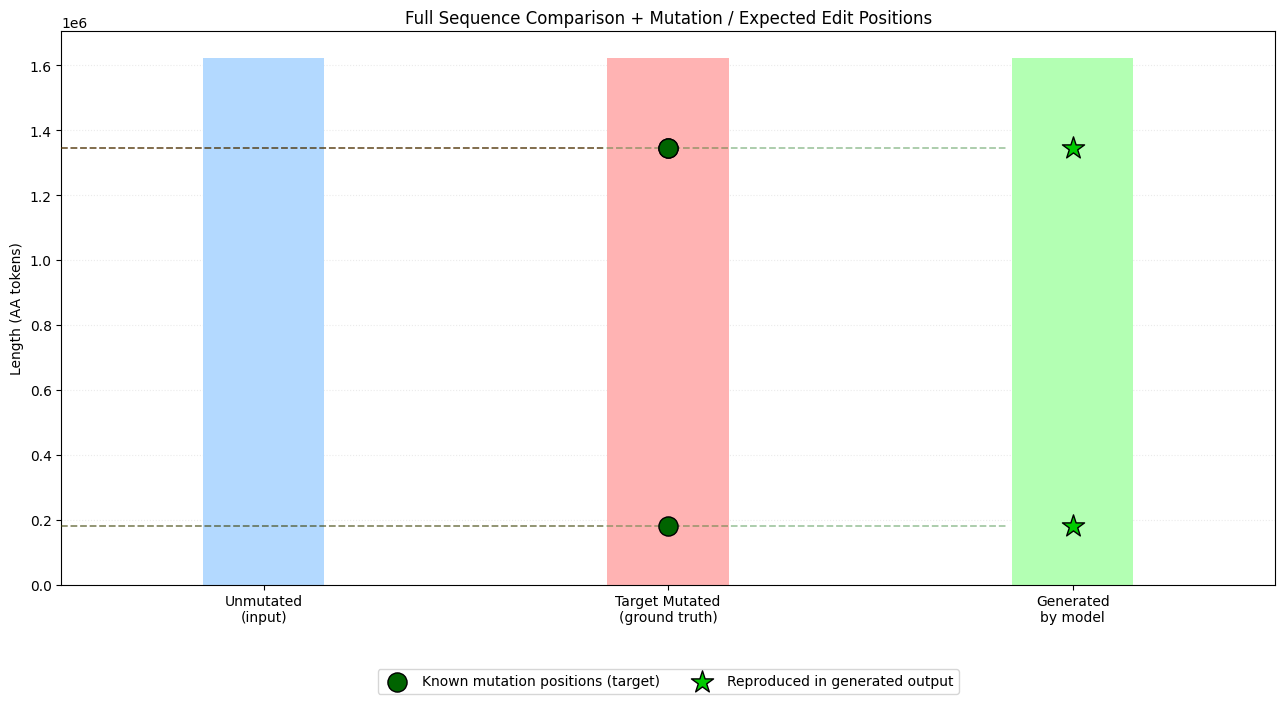

In [ ]:
unmut_len = len(unmut)
mut_len = len(mut)
gen_len = len(gen)

fig, ax = plt.subplots(figsize=(14, 6))

ax.bar(0, unmut_len, color='lightblue', width=0.3, label='Unmutated (input)')
ax.bar(1, mut_len, color='salmon', width=0.3, label='Target mutated')
ax.bar(2, gen_len, color='lightgreen', width=0.3, label='Generated')

if expected_positions:
    ax.scatter([1] * len(expected_positions), [mut_len * (p / mut_len) for p in expected_positions],
               c='lime', s=120, edgecolor='darkgreen', label='Expected mutation positions', zorder=10)

reproduced_positions = [row['position'] for row in rows if row['match']]
if reproduced_positions:
    ax.scatter([2] * len(reproduced_positions), [gen_len * (p / gen_len) for p in reproduced_positions],
               c='gold', s=140, edgecolor='black', label='Reproduced in generated output', zorder=11)

ax.set_xticks([0, 1, 2])
ax.set_xticklabels(['Unmutated', 'Target Mutated', 'Generated'])
ax.set_ylabel('Length (AA tokens)')
ax.set_title(f'Full Sequence Comparison + Mutation Positions ({genome_id})')
ax.legend()
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()